# Pairs Trading — EDA

**Input:** `data/interim/prices_clean.csv` (after outlier handling via `handle_outliers.py`)  
**Outputs:** `data/processed/returns.parquet`, `data/processed/log_prices.parquet`  

| # | Plot |
|---|------|
| 1 | Coverage Heatmap |
| 2 | Volatility Regimes |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf as sm_acf, adfuller
import statsmodels.api as sm

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook sits at project root (same level as data/, src/, outputs/)
PROJECT_ROOT = Path('.').resolve()
DATA_PATH    = PROJECT_ROOT / 'data' / 'interim' / 'prices_clean_eda_1.csv'
OUTPUT_DIR   = PROJECT_ROOT / 'outputs' / 'eda'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
MIN_TRADING_DAYS = 252
MAX_LAGS         = 20

print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Output dir   : {OUTPUT_DIR}')
print(f'Data exists  : {DATA_PATH.exists()}')

Project root : /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading
Data path    : /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/interim/prices_clean_eda_1.csv
Output dir   : /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/outputs/eda
Data exists  : True


## Load & prep

In [2]:
# prices_clean.csv is long-format: Date, Open, High, Low, Close, Volume, Ticker
all_stocks = pd.read_csv(DATA_PATH, parse_dates=['Date'])
all_stocks = all_stocks.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Rows    : {len(all_stocks):,}')
print(f'Tickers : {all_stocks["Ticker"].nunique():,}')
print(f'Dates   : {all_stocks["Date"].min().date()} to {all_stocks["Date"].max().date()}')
all_stocks.head()

Rows    : 3,987,379
Tickers : 1,000
Dates   : 1962-01-02 to 2017-11-10


,Date,Open,High,Low,Close,Volume,Ticker
0,1999-11-18,30.713,33.754,27.002,29.702,66277506,a
1,1999-11-19,28.986,29.027,26.872,27.257,16142920,a
2,1999-11-22,27.886,29.702,27.044,29.702,6970266,a
3,1999-11-23,28.688,29.446,27.002,27.002,6332082,a
4,1999-11-24,27.083,28.309,27.002,27.717,5132147,a


In [3]:
# Compute daily return, log price, and year columns
all_stocks['Return']    = all_stocks.groupby('Ticker')['Close'].pct_change()
all_stocks['Log_Price'] = np.log(all_stocks['Close'])
all_stocks['Year']      = all_stocks['Date'].dt.year

tickers  = all_stocks['Ticker'].unique().tolist()
n_stocks = len(tickers)

# Build return pivot (dates x tickers) — reused across all plots
print('Building return pivot matrix ...')
pivot_returns = all_stocks.pivot_table(index='Date', columns='Ticker', values='Return')

# Keep only stocks with >= MIN_TRADING_DAYS non-null returns
pivot_filtered = pivot_returns.dropna(thresh=MIN_TRADING_DAYS, axis=1)
n_filtered     = pivot_filtered.shape[1]

print(f'  {n_filtered} / {n_stocks} stocks have >= {MIN_TRADING_DAYS} trading days.')


Building return pivot matrix ...
  964 / 1000 stocks have >= 252 trading days.


---
## Save outputs
Preview `returns.wide` as a wide-format dataset of returns per stocks

In [4]:
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Wide format: dates as index, tickers as columns
returns_wide    = all_stocks.pivot_table(index='Date', columns='Ticker', values='Return')
log_prices_wide = all_stocks.pivot_table(index='Date', columns='Ticker', values='Log_Price')

# the code below saves returns and log_prices to parquet
# returns_wide.to_parquet(PROCESSED_DIR / 'returns.parquet')
# log_prices_wide.to_parquet(PROCESSED_DIR / 'log_prices.parquet')
# print(f'returns.parquet    -> {returns_wide.shape}    saved to {PROCESSED_DIR}')
# print(f'log_prices.parquet -> {log_prices_wide.shape}  saved to {PROCESSED_DIR}')
returns_wide.head()

Ticker,a,aa,aaba,aal,aaoi,aap,aapl,abb,abbv,abc,...,yumc,yy,z,zayo,zbh,zg,zion,znga,zto,zts
Date,,,,,,,,,,,,,,,,,,,,,
1962-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1962-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## Plot 1 — Coverage Heatmap

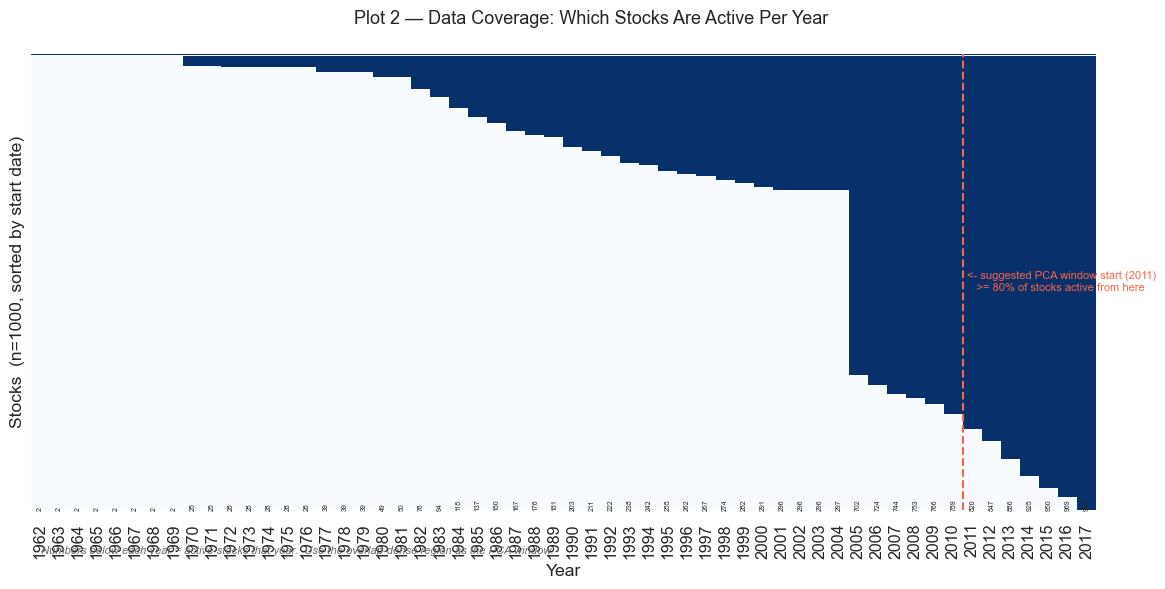

In [5]:
coverage = (
    all_stocks.groupby(['Ticker', 'Year'])['Return']
    .count()
    .unstack(fill_value=0)
)
coverage_binary = (coverage > 0).astype(int)

# Sort stocks by first year of data so heatmap reads chronologically
first_year      = coverage_binary.idxmax(axis=1)
coverage_binary = coverage_binary.loc[first_year.sort_values().index]

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Plot 2 — Data Coverage: Which Stocks Are Active Per Year', fontsize=13)

sns.heatmap(
    coverage_binary,
    cmap='Blues', cbar=False,
    xticklabels=True, yticklabels=False,
    linewidths=0, rasterized=True,
    ax=ax
)
ax.set_xlabel('Year')
ax.set_ylabel(f'Stocks  (n={n_stocks}, sorted by start date)')

# Count active stocks per year
active_per_year = coverage_binary.sum(axis=0)
for j, (yr, cnt) in enumerate(active_per_year.items()):
    ax.text(j + 0.5, len(coverage_binary) + 1.5,
            str(cnt), ha='center', va='bottom', fontsize=5, rotation=90)

# Mark suggested PCA window start: first year >= 80% stocks active
threshold_pct  = 0.80
pca_start_year = None
for yr, cnt in active_per_year.items():
    if cnt >= threshold_pct * n_stocks:
        pca_start_year = yr
        break

years_list = list(active_per_year.index)
if pca_start_year is not None:
    j_start = years_list.index(pca_start_year)
    ax.axvline(x=j_start, color='tomato', linewidth=1.5, linestyle='--')
    ax.text(
        j_start + 0.2, len(coverage_binary) * 0.5,
        f'<- suggested PCA window start ({pca_start_year})\n'
        f'   >= {int(threshold_pct*100)}% of stocks active from here',
        color='tomato', fontsize=8, va='center'
    )

ax.text(
    0.01, -0.08,
    'Numbers below each year = active stocks that year.  '
    'Use the overlap-dense region as the PCA window.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Plot 2 — Volatility Regimes

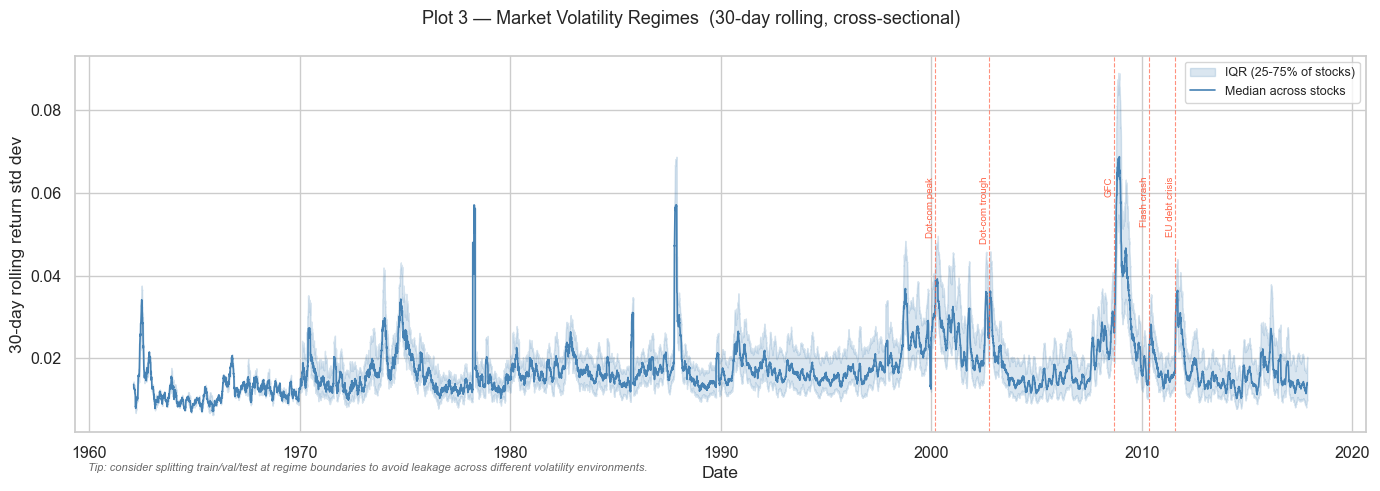

In [6]:
rolling_vol = pivot_filtered.rolling(30).std()
median_vol  = rolling_vol.median(axis=1).dropna()
p25_vol     = rolling_vol.quantile(0.25, axis=1).reindex(median_vol.index)
p75_vol     = rolling_vol.quantile(0.75, axis=1).reindex(median_vol.index)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Plot 3 — Market Volatility Regimes  (30-day rolling, cross-sectional)', fontsize=13)

ax.fill_between(median_vol.index, p25_vol, p75_vol,
                alpha=0.2, color='steelblue', label='IQR (25-75% of stocks)')
ax.plot(median_vol.index, median_vol, color='steelblue',
        linewidth=1.2, label='Median across stocks')

regime_events = {
    '2000-03': 'Dot-com peak',
    '2002-10': 'Dot-com trough',
    '2008-09': 'GFC',
    '2010-05': 'Flash crash',
    '2011-08': 'EU debt crisis',
}
for date_str, label in regime_events.items():
    x = pd.Timestamp(date_str)
    if median_vol.index.min() <= x <= median_vol.index.max():
        ax.axvline(x, color='tomato', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.text(x, float(median_vol.max()) * 0.93, label,
                color='tomato', fontsize=7, rotation=90, va='top', ha='right')

ax.set_xlabel('Date')
ax.set_ylabel('30-day rolling return std dev')
ax.legend(fontsize=9)
ax.text(
    0.01, -0.08,
    'Tip: consider splitting train/val/test at regime boundaries '
    'to avoid leakage across different volatility environments.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Summary

| Plot | Key finding | Implication |
|------|------------|-------------|
| 1. Coverage heatmap | >=80% coverage from ~2010 | PCA/clustering window starts 2010 |
| 2. Volatility regimes | Crisis spikes at 2000, 2008, 2010, 2011 | Align train/val/test to regime boundaries |